In [31]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./dataset.csv")

print("Shape:", df.shape)

print(df.dtypes.value_counts())

df.info(verbose=False, memory_usage="deep")

Shape: (11628, 671)
float64    643
str         25
object       2
int64        1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 11628 entries, 0 to 11627
Columns: 671 entries, Unnamed: 0 to rhythm.beats_position.99
dtypes: float64(643), int64(1), object(2), str(25)
memory usage: 100.9 MB


/var/folders/1g/vgpc5s_96vq2tz6m72rbtjlc0000gn/T/ipykernel_34529/563035214.py:1: DtypeWarning: Columns (0: Licensed, 1: official_video) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./dataset.csv")


In [3]:
nulls = df.isnull().sum().sort_values(ascending=False)
print(nulls[nulls > 0])

rhythm.beats_position.99    11625
rhythm.beats_position.98    11625
rhythm.beats_position.93    11624
rhythm.beats_position.97    11624
rhythm.beats_position.96    11624
                            ...  
Duration_ms                     1
Instrumentalness                1
Liveness                        1
Valence                         1
Tempo                           1
Length: 121, dtype: int64


In [4]:
# 1. Cuántas columnas beats_position hay (el grupo a eliminar)
beats_cols = [c for c in df.columns if c.startswith("rhythm.beats_position")]
print(f"Columnas beats_position: {len(beats_cols)}")

# 2. Distribución de nulos: cuántas columnas caen en cada rango de "vacío"
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
print("\nColumnas por nivel de nulos:")
print(f"  >90% nulos:   {(null_pct > 90).sum()}")
print(f"  50-90% nulos: {((null_pct > 50) & (null_pct <= 90)).sum()}")
print(f"  1-50% nulos:  {((null_pct > 0) & (null_pct <= 50)).sum()}")
print(f"  sin nulos:    {(null_pct == 0).sum()}")

Columnas beats_position: 100

Columnas por nivel de nulos:
  >90% nulos:   100
  50-90% nulos: 0
  1-50% nulos:  10
  sin nulos:    561


In [5]:
# 3. Columnas con nulos entre 1% y 90%: las que requieren decisión
intermedias = null_pct[(null_pct > 1) & (null_pct <= 90)].sort_values(ascending=False)
print("Columnas con nulos intermedios (requieren criterio):")
print(intermedias)

Columnas con nulos intermedios (requieren criterio):
Description    2.2
dtype: float64


In [6]:
# Eliminar las 100 columnas beats_position
beats_cols = [c for c in df.columns if c.startswith("rhythm.beats_position")]
df = df.drop(columns=beats_cols)
print("Nueva shape:", df.shape)   # debería ser (11628, 571)

Nueva shape: (11628, 571)


In [7]:
# Las columnas que aún tienen nulos, con su conteo exacto
null_count = df.isnull().sum()
con_nulos = null_count[null_count > 0].sort_values(ascending=False)
print(f"Columnas con nulos: {len(con_nulos)}")
print(con_nulos)

Columnas con nulos: 21
Description         261
Comments             93
Likes                79
Url_youtube          42
official_video       42
Licensed             42
Views                42
Channel              42
Title                42
Stream               10
Danceability          1
Energy                1
Tempo                 1
Valence               1
Liveness              1
Instrumentalness      1
Acousticness          1
Speechiness           1
Loudness              1
Key                   1
Duration_ms           1
dtype: int64


In [8]:
# ¿Cuántas filas tienen ALGÚN nulo en las columnas de targets?
target_cols = ["Stream", "Views", "Likes", "Comments"]
sin_completo = df[target_cols].isnull().any(axis=1).sum()
print(f"Filas con al menos un target nulo: {sin_completo} de {len(df)}")

# ¿Cuántas tienen TODOS los targets presentes (canción 100% utilizable)?
completas = df[target_cols].notnull().all(axis=1).sum()
print(f"Filas con los 4 targets completos: {completas}")

Filas con al menos un target nulo: 134 de 11628
Filas con los 4 targets completos: 11494


In [9]:
# Quedarnos solo con canciones que tienen los 4 targets
target_cols = ["Stream", "Views", "Likes", "Comments"]
df = df[df[target_cols].notnull().all(axis=1)].copy()
print("Shape tras filtrar targets:", df.shape)   # ~(11494, 571)

# Verificar qué nulos quedan (deberían ser solo Description y la fila rota de Spotify)
null_count = df.isnull().sum()
print("\nNulos restantes:")
print(null_count[null_count > 0].sort_values(ascending=False))

Shape tras filtrar targets: (11494, 571)

Nulos restantes:
Description         213
Danceability          1
Energy                1
Key                   1
Loudness              1
Speechiness           1
Acousticness          1
Instrumentalness      1
Liveness              1
Valence               1
Tempo                 1
Duration_ms           1
dtype: int64


In [12]:
# Solo columnas numéricas
num_df = df.select_dtypes(include=[np.number])

# 1. Varianza cero exacta: columnas constantes
const_cols = [c for c in num_df.columns if num_df[c].nunique() <= 1]
print(f"Columnas constantes (1 solo valor): {len(const_cols)}")
print(const_cols)

# 2. Casi constantes: el 99%+ de las filas comparten el mismo valor
casi_const = []
for c in num_df.columns:
    top_freq = num_df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.99:
        casi_const.append((c, round(top_freq, 3)))
print(f"\nColumnas casi constantes (>99% un valor): {len(casi_const)}")
for c, f in casi_const:
    print(f"  {c}: {f}")

Columnas constantes (1 solo valor): 6
['metadata.audio_properties.analysis.equal_loudness', 'metadata.audio_properties.analysis.sample_rate', 'metadata.audio_properties.analysis.start_time', 'metadata.audio_properties.lossless', 'metadata.audio_properties.number_channels', 'tonal.thpcp.0']

Columnas casi constantes (>99% un valor): 7
  metadata.audio_properties.analysis.equal_loudness: 1.0
  metadata.audio_properties.analysis.sample_rate: 1.0
  metadata.audio_properties.analysis.start_time: 1.0
  metadata.audio_properties.lossless: 1.0
  metadata.audio_properties.number_channels: 1.0
  metadata.audio_properties.sample_rate: 0.999
  tonal.thpcp.0: 1.0


In [13]:
# Todas las columnas del namespace metadata
meta_cols = [c for c in df.columns if c.startswith("metadata")]
print(f"Columnas metadata: {len(meta_cols)}")
for c in meta_cols:
    print(f"  {c}  (únicos: {df[c].nunique()})")

Columnas metadata: 16
  metadata.audio_properties.analysis.equal_loudness  (únicos: 1)
  metadata.audio_properties.analysis.length  (únicos: 8362)
  metadata.audio_properties.analysis.sample_rate  (únicos: 1)
  metadata.audio_properties.analysis.start_time  (únicos: 1)
  metadata.audio_properties.bit_rate  (únicos: 2577)
  metadata.audio_properties.length  (únicos: 8364)
  metadata.audio_properties.lossless  (únicos: 1)
  metadata.audio_properties.number_channels  (únicos: 1)
  metadata.audio_properties.replay_gain  (únicos: 10526)
  metadata.audio_properties.sample_rate  (únicos: 2)
  metadata.audio_properties.analysis.downmix  (únicos: 1)
  metadata.audio_properties.codec  (únicos: 2)
  metadata.audio_properties.md5_encoded  (únicos: 10543)
  metadata.version.essentia  (únicos: 1)
  metadata.version.essentia_git_sha  (únicos: 2)
  metadata.version.extractor  (únicos: 1)


In [14]:
# 1. Eliminar el namespace metadata completo (artefactos del archivo, no música)
meta_cols = [c for c in df.columns if c.startswith("metadata")]
df = df.drop(columns=meta_cols)
print(f"Eliminadas {len(meta_cols)} columnas metadata")

# 2. Eliminar columnas constantes (varianza cero) que NO sean metadata
num_df = df.select_dtypes(include=[np.number])
const_cols = [c for c in num_df.columns if num_df[c].nunique() <= 1]
df = df.drop(columns=const_cols)
print(f"Eliminadas {len(const_cols)} columnas constantes extra: {const_cols}")

print("\nShape actual:", df.shape)

Eliminadas 16 columnas metadata
Eliminadas 1 columnas constantes extra: ['tonal.thpcp.0']

Shape actual: (11494, 554)


In [15]:
# Features numéricas casi-constantes que SOBREVIVIERON (candidatas a revisar)
num_df = df.select_dtypes(include=[np.number])
casi = []
for c in num_df.columns:
    top = num_df[c].value_counts(normalize=True).iloc[0]
    if top > 0.95:   # 95%+ de las filas con el mismo valor
        casi.append((c, round(top, 3)))
print(f"Features audio casi-constantes (>95%): {len(casi)}")
for c, f in sorted(casi, key=lambda x: -x[1]):
    print(f"  {c}: {f}")

Features audio casi-constantes (>95%): 0


In [16]:
print("Shape actual:", df.shape)
print(df.dtypes.value_counts())

Shape actual: (11494, 554)
float64    532
str         19
object       2
int64        1
Name: count, dtype: int64


In [17]:
# Todas las columnas no-numéricas y una muestra de sus valores
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
print(f"Columnas categóricas/texto: {len(cat_cols)}\n")
for c in cat_cols:
    n = df[c].nunique()
    ejemplos = df[c].dropna().unique()[:4]
    print(f"  {c}  (únicos: {n})  ej: {list(ejemplos)}")

Columnas categóricas/texto: 21

  Artist  (únicos: 1559)  ej: ['Rascal Flatts', 'Valentín Elizalde', 'Asha Bhosle', 'Antonio Aguilar']
  Url_spotify  (únicos: 1559)  ej: ['https://open.spotify.com/artist/0a1gHP0HAqALbEyxaD5Ngn', 'https://open.spotify.com/artist/3CAhiUHkUYT1mFtVHM9SHA', 'https://open.spotify.com/artist/5as8A4G47Ohu9NSWs3Je8U', 'https://open.spotify.com/artist/0PN0fbe41KbuzlRYnoajNm']
  Track  (únicos: 10342)  ej: ["I Won't Let Go", 'Until Grace', 'Back To Life', 'Vete Ya']
  Album  (únicos: 7349)  ej: ['Nothing Like This', 'Citizen of Heaven', 'Back To Life', 'Mi Satisfacción']
  Album_type  (únicos: 3)  ej: ['album', 'single', 'compilation']
  Uri  (únicos: 10721)  ej: ['spotify:track:1T1C9VVQ1lb60WxWZx7KoG', 'spotify:track:52stVyuGiZ0QOWAAb27ZY4', 'spotify:track:7Lr4XaxGpkAwa37IVgg22k', 'spotify:track:3gqgSM82j6NMAj4Jllr06T']
  Url_youtube  (únicos: 10554)  ej: ['https://www.youtube.com/watch?v=4fqPcnuVPR8', 'https://www.youtube.com/watch?v=fPvsavY7lnc', 'https://www.

In [18]:
# 1. Identificadores y texto libre
id_cols = ["Artist", "Url_spotify", "Track", "Album", "Uri", "Url_youtube",
           "Title", "Channel", "Description", "track_id"]

# 2. Algoritmos de key redundantes (nos quedamos solo con edma)
redundant_key = ["tonal.key_krumhansl.key", "tonal.key_krumhansl.scale",
                 "tonal.key_temperley.key", "tonal.key_temperley.scale"]

df = df.drop(columns=[c for c in id_cols + redundant_key if c in df.columns])
print("Shape tras descartar IDs y keys redundantes:", df.shape)

# Confirmar qué columnas categóricas quedan
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
print(f"\nCategóricas restantes ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}  (únicos: {df[c].nunique()})")

Shape tras descartar IDs y keys redundantes: (11494, 540)

Categóricas restantes (7):
  Album_type  (únicos: 3)
  Licensed  (únicos: 2)
  official_video  (únicos: 2)
  tonal.chords_key  (únicos: 12)
  tonal.chords_scale  (únicos: 2)
  tonal.key_edma.key  (únicos: 12)
  tonal.key_edma.scale  (únicos: 2)


In [19]:
# Distribución de Stream en el nuevo dataset
print("--- Stream (crudo) ---")
print(df["Stream"].describe())
print(f"\nPercentiles clave:")
for p in [1, 25, 50, 75, 90, 99]:
    print(f"  P{p}: {df['Stream'].quantile(p/100):,.0f}")

# ¿Cuántos ceros o valores muy bajos hay?
print(f"\nCanciones con 0 streams: {(df['Stream'] == 0).sum()}")
print(f"Canciones con < 1000 streams: {(df['Stream'] < 1000).sum()}")

--- Stream (crudo) ---
count    1.149400e+04
mean     1.284929e+08
std      2.417305e+08
min      6.574000e+03
25%      1.545396e+07
50%      4.416165e+07
75%      1.260368e+08
max      3.362005e+09
Name: Stream, dtype: float64

Percentiles clave:
  P1: 522,523
  P25: 15,453,960
  P50: 44,161,650
  P75: 126,036,784
  P90: 327,847,724
  P99: 1,270,917,713

Canciones con 0 streams: 0
Canciones con < 1000 streams: 0


In [20]:
# success_score sobre log(Stream), escalado P1-P99
log_stream = np.log1p(df["Stream"])
p1  = log_stream.quantile(0.01)
p99 = log_stream.quantile(0.99)

s = log_stream.clip(p1, p99)
df["success_score"] = ((s - p1) / (p99 - p1) * 100).round(2)

print(f"Rango log usado: [{p1:.2f} , {p99:.2f}]")
print(df["success_score"].describe().round(2))

Rango log usado: [13.17 , 20.96]
count    11494.00
mean        56.23
std         20.55
min          0.00
25%         43.44
50%         56.91
75%         70.36
max        100.00
Name: success_score, dtype: float64


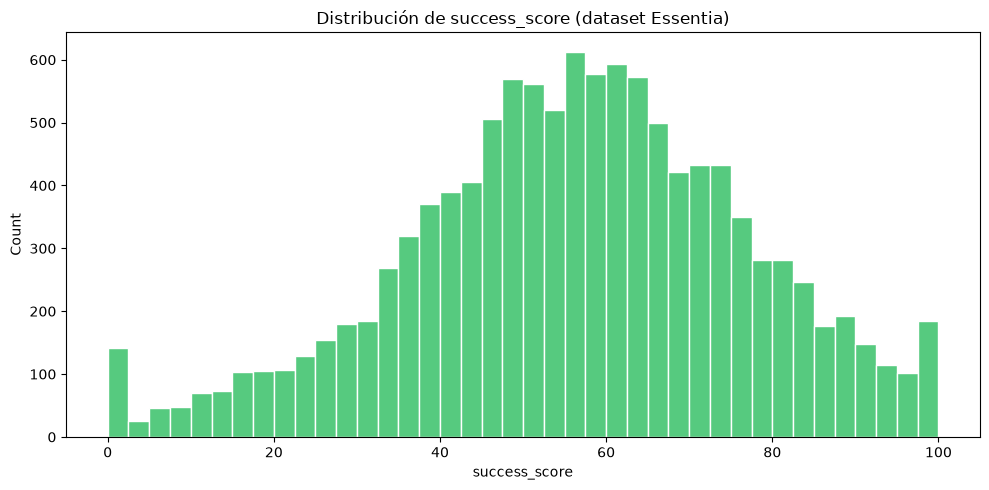

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["success_score"], bins=40, color="#1DB954", edgecolor="white")
plt.title("Distribución de success_score (dataset Essentia)")
plt.xlabel("success_score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [25]:
# Descartar features de audio viejas de Spotify (reemplazadas por Essentia)
spotify_audio = ["Danceability", "Energy", "Key", "Loudness", "Speechiness",
                 "Acousticness", "Instrumentalness", "Liveness", "Valence",
                 "Tempo", "Duration_ms"]
df = df.drop(columns=[c for c in spotify_audio if c in df.columns])
print("Shape tras descartar audio viejo de Spotify:", df.shape)

# Verificar qué columnas no-Essentia quedan (targets + categóricas que conservamos)
no_essentia = [c for c in df.columns if not c.startswith(("lowlevel", "rhythm", "tonal", "metadata"))]
print(f"\nColumnas que NO son features de Essentia ({len(no_essentia)}):")
print(no_essentia)

df = df.drop(columns=["Unnamed: 0"])
print("Shape final:", df.shape)   # (11494, 529)

Shape tras descartar audio viejo de Spotify: (11494, 530)

Columnas que NO son features de Essentia (9):
['Unnamed: 0', 'Album_type', 'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream', 'success_score']
Shape final: (11494, 529)


In [26]:
# Correlación de todas las features numéricas de Essentia con success_score
essentia_num = df.select_dtypes(include=[np.number]).drop(
    columns=["Stream", "Views", "Likes", "Comments", "success_score"]
)

corr_target = essentia_num.corrwith(df["success_score"]).dropna().sort_values()

print(f"Features numéricas analizadas: {len(corr_target)}")
print(f"\n--- Top 15 correlación NEGATIVA ---")
print(corr_target.head(15).round(3))
print(f"\n--- Top 15 correlación POSITIVA ---")
print(corr_target.tail(15).round(3))
print(f"\nCorrelación absoluta máxima: {corr_target.abs().max():.3f}")

Features numéricas analizadas: 517

--- Top 15 correlación NEGATIVA ---
tonal.chords_number_rate                        -0.098
lowlevel.spectral_energyband_middle_low.stdev   -0.093
lowlevel.melbands.stdev.4                       -0.085
tonal.tuning_frequency                          -0.084
lowlevel.erbbands.stdev.6                       -0.076
lowlevel.erbbands.stdev.5                       -0.074
lowlevel.spectral_energyband_middle_low.mean    -0.073
lowlevel.melbands.stdev.6                       -0.072
lowlevel.erbbands.stdev.8                       -0.071
lowlevel.barkbands.stdev.4                      -0.070
lowlevel.barkbands.stdev.6                      -0.069
lowlevel.barkbands.stdev.5                      -0.067
rhythm.beats_loudness_band_ratio.mean.1         -0.066
lowlevel.barkbands.mean.4                       -0.066
lowlevel.erbbands.mean.5                        -0.065
dtype: float64

--- Top 15 correlación POSITIVA ---
lowlevel.loudness_ebu128.short_term.stdev     0.099

In [34]:
corr_target = essentia_num.corrwith(df["success_score"]).dropna()
top40 = corr_target.abs().sort_values(ascending=False).head(40).index.tolist()

# Matriz de correlación absoluta entre las top-40, diagonal a 0 mediante .mask (crea copia)
corr_matrix = essentia_num[top40].corr().abs()
corr_matrix = corr_matrix.mask(np.eye(len(corr_matrix), dtype=bool), 0)

redundancia = (corr_matrix > 0.8).sum().sort_values(ascending=False)
print("Features del top-40 y cuántas otras del grupo las duplican (corr >0.8):")
print(redundancia[redundancia > 0])
print(f"\nFeatures sin ningún duplicado fuerte en el top-40: {(redundancia == 0).sum()}")

Features del top-40 y cuántas otras del grupo las duplican (corr >0.8):
lowlevel.spectral_contrast_valleys.stdev.5    11
lowlevel.spectral_rolloff.stdev               11
lowlevel.spectral_contrast_valleys.stdev.4    11
lowlevel.spectral_contrast_valleys.stdev.3    11
lowlevel.spectral_centroid.stdev              11
lowlevel.spectral_contrast_valleys.stdev.2    11
lowlevel.spectral_spread.stdev                11
lowlevel.spectral_contrast_valleys.stdev.0    11
lowlevel.loudness_ebu128.momentary.stdev      11
lowlevel.spectral_contrast_valleys.stdev.1    11
lowlevel.loudness_ebu128.short_term.stdev     10
lowlevel.zerocrossingrate.stdev               10
lowlevel.barkbands.stdev.15                    2
lowlevel.erbbands.stdev.21                     2
lowlevel.melbands.stdev.20                     2
lowlevel.barkbands.stdev.16                    2
lowlevel.erbbands.stdev.20                     2
lowlevel.melbands.stdev.21                     2
lowlevel.erbbands.stdev.6                     

In [35]:
corr_all = essentia_num.corr().abs()
upper = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
pares_redundantes = (upper > 0.95).sum().sum()

print(f"Pares de features con |corr| > 0.95: {pares_redundantes}")
print(f"Total de features: {essentia_num.shape[1]}")

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Features que se podrían eliminar por redundancia (>0.95): {len(to_drop)}")
print(f"Features que sobrevivirían: {essentia_num.shape[1] - len(to_drop)}")

Pares de features con |corr| > 0.95: 218
Total de features: 517
Features que se podrían eliminar por redundancia (>0.95): 139
Features que sobrevivirían: 378


In [36]:
# Features ordenadas por correlación absoluta con el target (de mayor a menor)
corr_target = essentia_num.corrwith(df["success_score"]).dropna()
ranked = corr_target.abs().sort_values(ascending=False).index.tolist()

# Matriz de correlación absoluta entre todas (para chequear redundancia)
corr_all = essentia_num.corr().abs()

# Selección greedy: aceptar una feature solo si no duplica (>0.8) a las ya elegidas
selected = []
for feat in ranked:
    if all(corr_all.loc[feat, s] <= 0.8 for s in selected):
        selected.append(feat)
    if len(selected) >= 50:   # presupuesto de ~50 features
        break

print(f"Features seleccionadas (diversas, top por correlación): {len(selected)}")
for f in selected:
    print(f"  {f}: {corr_target[f]:+.3f}")

Features seleccionadas (diversas, top por correlación): 50
  lowlevel.spectral_contrast_valleys.stdev.5: +0.153
  lowlevel.spectral_complexity.stdev: +0.142
  lowlevel.melbands_spread.stdev: +0.109
  lowlevel.gfcc.mean.7: +0.103
  lowlevel.spectral_entropy.stdev: +0.099
  tonal.chords_number_rate: -0.098
  lowlevel.spectral_contrast_coeffs.stdev.3: +0.095
  lowlevel.spectral_energyband_middle_low.stdev: -0.093
  tonal.hpcp_entropy.stdev: +0.092
  lowlevel.erbbands.stdev.21: +0.090
  lowlevel.spectral_contrast_coeffs.stdev.5: +0.087
  lowlevel.erbbands.stdev.20: +0.087
  lowlevel.melbands.stdev.4: -0.085
  tonal.tuning_frequency: -0.084
  lowlevel.spectral_contrast_coeffs.stdev.4: +0.083
  rhythm.beats_loudness_band_ratio.stdev.0: +0.082
  tonal.chords_histogram.23: +0.081
  lowlevel.spectral_centroid.mean: +0.081
  lowlevel.erbbands.stdev.22: +0.078
  lowlevel.gfcc.mean.5: +0.077
  lowlevel.barkbands.stdev.19: +0.076
  tonal.chords_strength.stdev: +0.076
  lowlevel.silence_rate_60dB.st

In [37]:
# Las 50 features seleccionadas (ya están en 'selected')
feature_cols = selected.copy()

# Categóricas a incluir (tonales de Essentia + las de tu dataset)
cat_cols = ["tonal.key_edma.key", "tonal.key_edma.scale",
            "tonal.chords_key", "tonal.chords_scale",
            "Album_type", "Licensed", "official_video"]
cat_cols = [c for c in cat_cols if c in df.columns]

# Construir X: numéricas seleccionadas + one-hot de categóricas
X = df[feature_cols + cat_cols].copy()
X = pd.get_dummies(X, columns=cat_cols)

# Target de Capa 1
y = df["success_score"]

print(f"X shape: {X.shape}")
print(f"Features numéricas: {len(feature_cols)} | Total tras one-hot: {X.shape[1]}")
print(f"y shape: {y.shape}")

X shape: (11494, 85)
Features numéricas: 50 | Total tras one-hot: 85
y shape: (11494,)


In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline

# Escalado dentro de un pipeline para que el CV lo aplique correctamente por fold
modelos = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
}

print("=== CAPA 1 (success_score) — Validación cruzada 5-fold ===\n")
print(f"{'Modelo':<16}{'R² medio':>12}{'Std':>10}")
print("-" * 38)
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring="r2", n_jobs=-1)
    print(f"{nombre:<16}{scores.mean():>12.4f}{scores.std():>10.4f}")

=== CAPA 1 (success_score) — Validación cruzada 5-fold ===

Modelo              R² medio       Std
--------------------------------------
Ridge                 0.0022    0.0720
RandomForest          0.0912    0.0681
XGBoost               0.0607    0.0866


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# X con TODAS las features de Essentia numéricas + categóricas one-hot
essentia_num = df.select_dtypes(include=[np.number]).drop(
    columns=["Stream", "Views", "Likes", "Comments", "success_score"]
)
cat_cols = ["tonal.key_edma.key", "tonal.key_edma.scale",
            "tonal.chords_key", "tonal.chords_scale",
            "Album_type", "Licensed", "official_video"]
cat_cols = [c for c in cat_cols if c in df.columns]

X_full = pd.concat([essentia_num, pd.get_dummies(df[cat_cols], columns=cat_cols)], axis=1)
y = df["success_score"]

# Split ANTES de seleccionar (evita leakage de selección)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42)

print(f"X_full shape: {X_full.shape}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

X_full shape: (11494, 552)
Train: (9195, 552) | Test: (2299, 552)


In [41]:
# RF sobre todas las features, solo en train, para extraer importancias
rf_selector = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Ranking de importancia
importancias = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

print("Top 30 features por importancia (Random Forest, no-lineal):")
print(importancias.head(30).round(4))
print(f"\nImportancia acumulada del top-50: {importancias.head(50).sum():.3f}")
print(f"Importancia acumulada del top-80: {importancias.head(80).sum():.3f}")

Top 30 features por importancia (Random Forest, no-lineal):
Album_type_album                              0.0277
lowlevel.spectral_contrast_valleys.stdev.5    0.0236
lowlevel.spectral_complexity.stdev            0.0132
lowlevel.erbbands.stdev.39                    0.0109
rhythm.onset_rate                             0.0088
rhythm.beats_count                            0.0081
lowlevel.erbbands.mean.39                     0.0075
tonal.chords_number_rate                      0.0063
lowlevel.erbbands_flatness_db.stdev           0.0058
official_video_True                           0.0053
lowlevel.spectral_contrast_coeffs.stdev.3     0.0052
lowlevel.spectral_contrast_coeffs.mean.2      0.0051
lowlevel.spectral_contrast_coeffs.stdev.2     0.0049
lowlevel.erbbands.stdev.22                    0.0048
tonal.chords_histogram.23                     0.0047
lowlevel.loudness_ebu128.loudness_range       0.0046
lowlevel.spectral_contrast_coeffs.stdev.4     0.0045
lowlevel.loudness_ebu128.short_term.std

In [42]:
from sklearn.model_selection import cross_val_score

# Features ordenadas por importancia (del RF selector, ya entrenado en train)
ranked_features = importancias.index.tolist()

print("=== Barrido de K (Random Forest, 5-fold CV en train) ===\n")
print(f"{'K features':<12}{'R² medio':>12}{'Std':>10}")
print("-" * 34)

for k in [50, 100, 150, 250, 400, 552]:
    feats_k = ranked_features[:k]
    rf = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train[feats_k], y_train, cv=5, scoring="r2", n_jobs=-1)
    print(f"{k:<12}{scores.mean():>12.4f}{scores.std():>10.4f}")

=== Barrido de K (Random Forest, 5-fold CV en train) ===

K features      R² medio       Std
----------------------------------
50                0.2213    0.0078
100               0.2229    0.0085
150               0.2230    0.0087
250               0.2190    0.0072
400               0.2164    0.0095
552               0.2157    0.0095


In [45]:
feats_50 = importancias.index.tolist()[:50]

# Modelo final con los parámetros que ya venían rindiendo
rf_final = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1)
rf_final.fit(X_train[feats_50], y_train)

# Evaluación sobre el test que nunca se tocó
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred = rf_final.predict(X_test[feats_50])
print("=== MODELO FINAL CAPA 1 (test apartado) ===")
print(f"  R²  : {r2_score(y_test, y_pred):.4f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred):.2f} puntos (sobre 100)")

=== MODELO FINAL CAPA 1 (test apartado) ===
  R²  : 0.2290
  MAE : 13.98 puntos (sobre 100)


In [46]:
import joblib

# Guardar el modelo y la lista de features juntos
joblib.dump({
    "model": rf_final,
    "features": feats_50,
}, "modelo_capa1_success.pkl")

print("Guardado: modelo_capa1_success.pkl")
print(f"Features que la app debe generar con Essentia: {len(feats_50)}")

Guardado: modelo_capa1_success.pkl
Features que la app debe generar con Essentia: 50


In [47]:
from sklearn.model_selection import cross_val_predict

# success_score predicho de forma honesta:
#   - train: out-of-fold (cross_val_predict)
#   - test:  predicción del modelo ya entrenado
success_pred_train = cross_val_predict(
    RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                          random_state=42, n_jobs=-1),
    X_train[feats_50], y_train, cv=5, n_jobs=-1)
success_pred_test = rf_final.predict(X_test[feats_50])

print("success_score predicho generado (train OOF + test)")
print(f"  train: {success_pred_train.shape} | test: {success_pred_test.shape}")

success_score predicho generado (train OOF + test)
  train: (9195,) | test: (2299,)


In [48]:
# Targets de YouTube en log1p, alineados al split
y_youtube = np.log1p(df[["Views", "Likes", "Comments"]])

y_yt_train = y_youtube.loc[X_train.index]
y_yt_test  = y_youtube.loc[X_test.index]

print("Targets YouTube (log) alineados:")
print(f"  train: {y_yt_train.shape} | test: {y_yt_test.shape}")

Targets YouTube (log) alineados:
  train: (9195, 3) | test: (2299, 3)


In [49]:
print("Índices alineados:", X_train.index.equals(y_yt_train.index))

Índices alineados: True


In [50]:
# Un RF selector por target, sobre TODAS las features de Essentia (en train)
importancias_por_target = {}
for target in ["Views", "Likes", "Comments"]:
    rf_sel = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=42, n_jobs=-1)
    rf_sel.fit(X_train, y_yt_train[target])
    importancias_por_target[target] = pd.Series(
        rf_sel.feature_importances_, index=X_train.columns)
    print(f"  RF selector entrenado para {target}")

# Importancia promedio entre los tres targets
imp_promedio = pd.DataFrame(importancias_por_target).mean(axis=1).sort_values(ascending=False)

print("\nTop 30 features compartidas (importancia promedio sobre los 3 targets):")
print(imp_promedio.head(30).round(4))

  RF selector entrenado para Views
  RF selector entrenado para Likes
  RF selector entrenado para Comments

Top 30 features compartidas (importancia promedio sobre los 3 targets):
official_video_False                          0.0805
official_video_True                           0.0523
rhythm.beats_count                            0.0270
lowlevel.erbbands.mean.34                     0.0264
lowlevel.spectral_contrast_valleys.stdev.5    0.0258
lowlevel.melbands_crest.stdev                 0.0100
lowlevel.erbbands.mean.29                     0.0086
tonal.chords_number_rate                      0.0080
lowlevel.erbbands.mean.35                     0.0076
rhythm.onset_rate                             0.0071
lowlevel.spectral_contrast_coeffs.stdev.2     0.0069
lowlevel.gfcc.mean.7                          0.0063
lowlevel.spectral_contrast_coeffs.stdev.3     0.0062
lowlevel.erbbands.mean.33                     0.0060
rhythm.bpm                                    0.0055
rhythm.beats_loudness_ba

In [51]:
from sklearn.model_selection import cross_val_score

ranked_yt = imp_promedio.index.tolist()

# Función para armar X de Capa 2: top-K features + success_pred como columna extra
def build_X_layer2(k):
    feats_k = ranked_yt[:k]
    X_tr = X_train[feats_k].copy()
    X_tr["predicted_success"] = success_pred_train
    X_te = X_test[feats_k].copy()
    X_te["predicted_success"] = success_pred_test
    return X_tr, X_te

# Barrido de K usando Views como referencia (los 3 targets son casi idénticos)
print("=== Barrido de K — Capa 2 (Views, 5-fold CV en train) ===\n")
print(f"{'K features':<12}{'R² medio':>12}{'Std':>10}")
print("-" * 34)
for k in [30, 50, 100, 150, 250]:
    X_tr, _ = build_X_layer2(k)
    rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                               random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_tr, y_yt_train["Views"], cv=5, scoring="r2", n_jobs=-1)
    print(f"{k:<12}{scores.mean():>12.4f}{scores.std():>10.4f}")

=== Barrido de K — Capa 2 (Views, 5-fold CV en train) ===

K features      R² medio       Std
----------------------------------
30                0.3472    0.0129
50                0.3518    0.0127
100               0.3496    0.0102
150               0.3500    0.0097
250               0.3457    0.0106


In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

# X de Capa 2 con K=50 (mismas 50 features compartidas + predicted_success)
X_tr_l2, X_te_l2 = build_X_layer2(50)

modelos_l2 = {}
print("=== MODELOS FINALES CAPA 2 (test apartado) ===\n")
for target in ["Views", "Likes", "Comments"]:
    rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr_l2, y_yt_train[target])
    pred_log = rf.predict(X_te_l2)

    # R² en escala log (donde entrenó); MAE revertido a escala real
    r2 = r2_score(y_yt_test[target], pred_log)
    mae_real = mean_absolute_error(np.expm1(y_yt_test[target]), np.expm1(pred_log))

    print(f"{target}:")
    print(f"   R²  (log)        : {r2:.4f}")
    print(f"   MAE (escala real): {mae_real:,.0f}")
    modelos_l2[target] = rf

=== MODELOS FINALES CAPA 2 (test apartado) ===

Views:
   R²  (log)        : 0.3562
   MAE (escala real): 75,327,228
Likes:
   R²  (log)        : 0.3678
   MAE (escala real): 533,783
Comments:
   R²  (log)        : 0.3394
   MAE (escala real): 20,864


In [53]:
import joblib

joblib.dump({
    "models": modelos_l2,                          # dict: Views, Likes, Comments
    "features": ranked_yt[:50],                     # las 50 features compartidas
    "uses_predicted_success": True,                 # recordatorio: añadir esa columna
}, "modelo_capa2_youtube.pkl")

print("Guardado: modelo_capa2_youtube.pkl")

Guardado: modelo_capa2_youtube.pkl


In [1]:
import json

feats_50 = importancias.index.tolist()[:50]

# Separar features one-hot (categóricas) de las numéricas crudas de Essentia
# Las one-hot tienen el patrón "columnaoriginal_valor"
cat_prefixes = ["tonal.key_edma.key", "tonal.key_edma.scale",
                "tonal.chords_key", "tonal.chords_scale",
                "Album_type", "Licensed", "official_video"]

numericas_crudas = []
onehot = []
for f in feats_50:
    if any(f.startswith(p + "_") for p in cat_prefixes):
        onehot.append(f)
    else:
        numericas_crudas.append(f)

print(f"Total features Capa 1: {len(feats_50)}")
print(f"  Numéricas crudas de Essentia (filtrar directo): {len(numericas_crudas)}")
print(f"  Columnas one-hot (generar tras categóricas): {len(onehot)}")

# Guardar todo en un JSON estructurado para el backend
config_capa1 = {
    "all_features_ordered": feats_50,          # orden EXACTO que espera el modelo
    "essentia_numeric": numericas_crudas,      # filtrar directo del output de Essentia
    "onehot_columns": onehot,                  # generar aplicando one-hot a las categóricas
}

with open("capa1_features.json", "w") as f:
    json.dump(config_capa1, f, indent=2, ensure_ascii=False)

print("\nGuardado: capa1_features.json")

NameError: name 'importancias' is not defined

In [3]:
import os

# ¿Existe el modelo guardado?
print("model_layer1_success.pkl existe:", os.path.exists("model_layer1_success.pkl"))

# Listar los .pkl que haya en la carpeta
pkls = [f for f in os.listdir(".") if f.endswith(".pkl")]
print("Archivos .pkl encontrados:", pkls)

model_layer1_success.pkl existe: True
Archivos .pkl encontrados: ['model_layer2_youtube.pkl', 'model_layer1_success.pkl']


In [4]:
import joblib
data = joblib.load("model_layer1_success.pkl")
print(data["features"])

['Album_type_album', 'lowlevel.spectral_contrast_valleys.stdev.5', 'lowlevel.spectral_complexity.stdev', 'lowlevel.erbbands.stdev.39', 'rhythm.onset_rate', 'rhythm.beats_count', 'lowlevel.erbbands.mean.39', 'tonal.chords_number_rate', 'lowlevel.erbbands_flatness_db.stdev', 'official_video_True', 'lowlevel.spectral_contrast_coeffs.stdev.3', 'lowlevel.spectral_contrast_coeffs.mean.2', 'lowlevel.spectral_contrast_coeffs.stdev.2', 'lowlevel.erbbands.stdev.22', 'tonal.chords_histogram.23', 'lowlevel.loudness_ebu128.loudness_range', 'lowlevel.spectral_contrast_coeffs.stdev.4', 'lowlevel.loudness_ebu128.short_term.stdev', 'lowlevel.gfcc.mean.12', 'lowlevel.mfcc.mean.6', 'lowlevel.melbands_crest.stdev', 'rhythm.beats_loudness_band_ratio.stdev.0', 'lowlevel.loudness_ebu128.momentary.stdev', 'lowlevel.spectral_contrast_coeffs.stdev.1', 'lowlevel.spectral_flux.mean', 'official_video_False', 'lowlevel.gfcc.mean.10', 'lowlevel.spectral_contrast_coeffs.mean.3', 'tonal.chords_histogram.4', 'rhythm.be

In [5]:
import json

feats_50 = ['Album_type_album', 'lowlevel.spectral_contrast_valleys.stdev.5', 'lowlevel.spectral_complexity.stdev', 'lowlevel.erbbands.stdev.39', 'rhythm.onset_rate', 'rhythm.beats_count', 'lowlevel.erbbands.mean.39', 'tonal.chords_number_rate', 'lowlevel.erbbands_flatness_db.stdev', 'official_video_True', 'lowlevel.spectral_contrast_coeffs.stdev.3', 'lowlevel.spectral_contrast_coeffs.mean.2', 'lowlevel.spectral_contrast_coeffs.stdev.2', 'lowlevel.erbbands.stdev.22', 'tonal.chords_histogram.23', 'lowlevel.loudness_ebu128.loudness_range', 'lowlevel.spectral_contrast_coeffs.stdev.4', 'lowlevel.loudness_ebu128.short_term.stdev', 'lowlevel.gfcc.mean.12', 'lowlevel.mfcc.mean.6', 'lowlevel.melbands_crest.stdev', 'rhythm.beats_loudness_band_ratio.stdev.0', 'lowlevel.loudness_ebu128.momentary.stdev', 'lowlevel.spectral_contrast_coeffs.stdev.1', 'lowlevel.spectral_flux.mean', 'official_video_False', 'lowlevel.gfcc.mean.10', 'lowlevel.spectral_contrast_coeffs.mean.3', 'tonal.chords_histogram.4', 'rhythm.beats_loudness_band_ratio.stdev.5', 'tonal.tuning_diatonic_strength', 'lowlevel.mfcc.mean.8', 'lowlevel.spectral_contrast_coeffs.stdev.0', 'lowlevel.mfcc.mean.7', 'lowlevel.loudness_ebu128.momentary.mean', 'lowlevel.dynamic_complexity', 'tonal.chords_histogram.7', 'lowlevel.gfcc.mean.11', 'tonal.thpcp.14', 'tonal.chords_strength.stdev', 'lowlevel.gfcc.mean.7', 'lowlevel.gfcc.mean.6', 'tonal.chords_histogram.0', 'lowlevel.loudness_ebu128.integrated', 'tonal.thpcp.11', 'tonal.chords_histogram.22', 'lowlevel.erbbands_crest.stdev', 'rhythm.danceability', 'lowlevel.spectral_centroid.stdev', 'tonal.chords_strength.mean']

# Separar por origen
onehot = [f for f in feats_50 if f.startswith(("Album_type_", "official_video_", "Licensed_",
                                               "tonal.key_edma.key_", "tonal.key_edma.scale_",
                                               "tonal.chords_key_", "tonal.chords_scale_"))]
essentia_numeric = [f for f in feats_50 if f not in onehot]

config = {
    "all_features_ordered": feats_50,        # ORDEN EXACTO que espera el modelo
    "essentia_numeric": essentia_numeric,    # filtrar directo del output de Essentia
    "onehot_columns": onehot,                # generar desde metadata (no de Essentia)
}

with open("capa1_features.json", "w") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Numéricas de Essentia (filtrar directo): {len(essentia_numeric)}")
print(f"One-hot (generar desde metadata): {len(onehot)} -> {onehot}")
print("\nGuardado: capa1_features.json")

Numéricas de Essentia (filtrar directo): 47
One-hot (generar desde metadata): 3 -> ['Album_type_album', 'official_video_True', 'official_video_False']

Guardado: capa1_features.json


In [7]:
import os, joblib, json

print("model_layer2_youtube.pkl existe:", os.path.exists("model_layer2_youtube.pkl"))

if os.path.exists("model_layer2_youtube.pkl"):
    data2 = joblib.load("model_layer2_youtube.pkl")
    feats_50_l2 = data2["features"]
    print(f"\nFeatures Capa 2 ({len(feats_50_l2)}):")
    print(feats_50_l2)

model_layer2_youtube.pkl existe: True

Features Capa 2 (50):
['official_video_False', 'official_video_True', 'rhythm.beats_count', 'lowlevel.erbbands.mean.34', 'lowlevel.spectral_contrast_valleys.stdev.5', 'lowlevel.melbands_crest.stdev', 'lowlevel.erbbands.mean.29', 'tonal.chords_number_rate', 'lowlevel.erbbands.mean.35', 'rhythm.onset_rate', 'lowlevel.spectral_contrast_coeffs.stdev.2', 'lowlevel.gfcc.mean.7', 'lowlevel.spectral_contrast_coeffs.stdev.3', 'lowlevel.erbbands.mean.33', 'rhythm.bpm', 'rhythm.beats_loudness_band_ratio.stdev.0', 'lowlevel.spectral_centroid.stdev', 'lowlevel.loudness_ebu128.short_term.stdev', 'lowlevel.spectral_contrast_coeffs.stdev.4', 'lowlevel.spectral_contrast_valleys.mean.0', 'Album_type_single', 'lowlevel.pitch_salience.stdev', 'rhythm.bpm_histogram_second_peak_weight', 'lowlevel.loudness_ebu128.integrated', 'lowlevel.barkbands.mean.24', 'lowlevel.spectral_contrast_coeffs.stdev.5', 'tonal.hpcp.stdev.14', 'lowlevel.spectral_contrast_coeffs.stdev.1', 'lo

In [9]:
import json

feats_50_l2 = ['official_video_False', 'official_video_True', 'rhythm.beats_count', 'lowlevel.erbbands.mean.34', 'lowlevel.spectral_contrast_valleys.stdev.5', 'lowlevel.melbands_crest.stdev', 'lowlevel.erbbands.mean.29', 'tonal.chords_number_rate', 'lowlevel.erbbands.mean.35', 'rhythm.onset_rate', 'lowlevel.spectral_contrast_coeffs.stdev.2', 'lowlevel.gfcc.mean.7', 'lowlevel.spectral_contrast_coeffs.stdev.3', 'lowlevel.erbbands.mean.33', 'rhythm.bpm', 'rhythm.beats_loudness_band_ratio.stdev.0', 'lowlevel.spectral_centroid.stdev', 'lowlevel.loudness_ebu128.short_term.stdev', 'lowlevel.spectral_contrast_coeffs.stdev.4', 'lowlevel.spectral_contrast_valleys.mean.0', 'Album_type_single', 'lowlevel.pitch_salience.stdev', 'rhythm.bpm_histogram_second_peak_weight', 'lowlevel.loudness_ebu128.integrated', 'lowlevel.barkbands.mean.24', 'lowlevel.spectral_contrast_coeffs.stdev.5', 'tonal.hpcp.stdev.14', 'lowlevel.spectral_contrast_coeffs.stdev.1', 'lowlevel.spectral_complexity.stdev', 'lowlevel.loudness_ebu128.short_term.mean', 'rhythm.bpm_histogram_first_peak_weight', 'lowlevel.loudness_ebu128.loudness_range', 'lowlevel.erbbands.mean.39', 'lowlevel.erbbands.mean.30', 'tonal.hpcp_entropy.stdev', 'lowlevel.barkbands.stdev.0', 'lowlevel.barkbands_crest.stdev', 'lowlevel.spectral_spread.stdev', 'lowlevel.spectral_spread.mean', 'lowlevel.spectral_strongpeak.stdev', 'lowlevel.gfcc.mean.9', 'lowlevel.erbbands.stdev.34', 'tonal.chords_histogram.19', 'lowlevel.spectral_contrast_coeffs.mean.2', 'lowlevel.gfcc.mean.11', 'rhythm.beats_loudness_band_ratio.stdev.3', 'lowlevel.erbbands_crest.mean', 'tonal.chords_histogram.23', 'lowlevel.erbbands.stdev.35', 'lowlevel.erbbands.mean.4']

# Separar por origen
onehot_l2 = [f for f in feats_50_l2 if f.startswith(("Album_type_", "official_video_", "Licensed_",
                                                     "tonal.key_edma.key_", "tonal.key_edma.scale_",
                                                     "tonal.chords_key_", "tonal.chords_scale_"))]
essentia_numeric_l2 = [f for f in feats_50_l2 if f not in onehot_l2]

# El modelo espera las 50 features + predicted_success al final (orden de construcción en entrenamiento)
all_features_l2 = feats_50_l2 + ["predicted_success"]

config_l2 = {
    "all_features_ordered": all_features_l2,        # 51 columnas: las 50 + predicted_success al final
    "essentia_numeric": essentia_numeric_l2,        # filtrar directo del output de Essentia
    "onehot_columns": onehot_l2,                    # hardcodear desde metadata
    "requires_predicted_success": True,             # inyectar la salida de la Capa 1
    "predicted_success_position": "last",           # va como última columna
}

with open("capa2_features.json", "w") as f:
    json.dump(config_l2, f, indent=2, ensure_ascii=False)

print(f"Numéricas de Essentia: {len(essentia_numeric_l2)}")
print(f"One-hot (hardcodear): {len(onehot_l2)} -> {onehot_l2}")
print(f"Total columnas que espera el modelo: {len(all_features_l2)} (50 + predicted_success)")
print("\nGuardado: capa2_features.json")

Numéricas de Essentia: 47
One-hot (hardcodear): 3 -> ['official_video_False', 'official_video_True', 'Album_type_single']
Total columnas que espera el modelo: 51 (50 + predicted_success)

Guardado: capa2_features.json
